# Part 2: Visualizing the Proposed 4D Feature Space
In this notebook, we simulate a single round of FL, extract the 4D feature vectors (Norm, Cosine, CKA Global, CKA Mean) for 10 clients, and use PCA to visualize how our algorithm isolates attackers.


In [5]:
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from proposed.models.lenet import LeNet5
from proposed.attacks.poisoning import sign_flip_attack
from proposed.aggregation.proposed import extract_features


### 2.1 Simulate Client Updates


In [6]:
# Initialize global model and 10 local client models
global_model = LeNet5()
global_weights = global_model.state_dict()

# In real FL, all benign clients share a common underlying true gradient direction.
true_gradient = {k: torch.randn_like(v) * 0.1 for k, v in global_weights.items()}

client_updates = []
labels = [] # 0 for benign, 1 for attacker

# Simulate 7 Benign Clients (Common direction + Non-IID noise)
for i in range(7):
    local_w = {k: v + true_gradient[k] + torch.randn_like(v)*0.02 for k, v in global_weights.items()}
    client_updates.append((local_w, 1000))
    labels.append(0)

# Simulate 3 Attackers (Sign-Flip Attack)
for i in range(3):
    # We flip the update of the first 3 benign clients to act as attackers
    attacker_w = sign_flip_attack(client_updates[i][0], global_weights)
    client_updates.append((attacker_w, 1000))
    labels.append(1)


### 2.2 Extract 4D Features (Norm, Cosine, CKA_G, CKA_M)


In [7]:
features = extract_features(client_updates, global_weights)
print("Feature Matrix Shape:", features.shape)
print("Features (First Client):", features[0])


Feature Matrix Shape: (10, 4)
Features (First Client): [21.49304962  0.97596908  0.6624921   0.91329378]


### 2.3 PCA Projection & Clustering Visualization


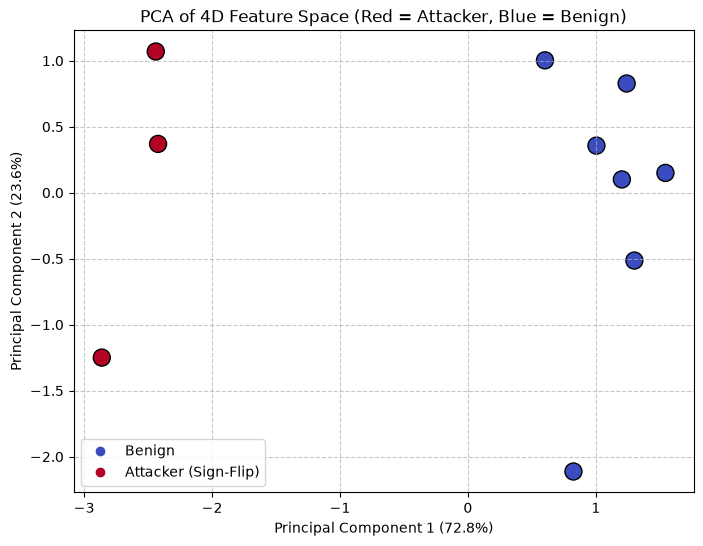

In [8]:
# Standardize the features for PCA
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Reduce to 2 dimensions using PCA
pca = PCA(n_components=2)
features_2d = pca.fit_transform(scaled_features)

# Plot the results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels, cmap='coolwarm', s=150, edgecolors='k')
plt.title('PCA of 4D Feature Space (Red = Attacker, Blue = Benign)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# Create a legend
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Benign', 'Attacker (Sign-Flip)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
